<a href="https://colab.research.google.com/github/kaelasyadira/2311531001-kaelaassyurasyadira-ImageProcessing/blob/main/IP_TugasPertemuan5_2311531001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

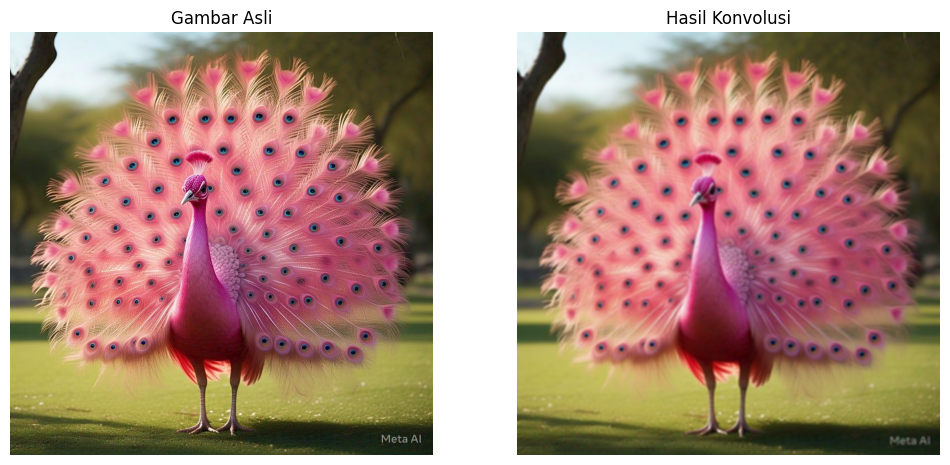

In [6]:
import numpy as np #mengelola matriks dan operasi numerik
from PIL import Image #membaca gambar dari file
import matplotlib.pyplot as plt #menampilkan gambar sebelum dan sesudah konvolusi

#membaca citra yang diinputkan
try:
    img_np = np.array(Image.open('Peacock.jpg'))
except FileNotFoundError:
    print("Error: File tidak ditemukan. coba ulangi.")

#membuat kernel 5x5 yang nantinya menghasilkan efek average blur
kernel = np.ones((5, 5), dtype=np.float32) / 25.0

#menyiapkan variabel dasar yang akan digunakan untuk operasi
height, width, channels = img_np.shape
output = np.zeros_like(img_np, dtype=np.float32)

#konvolusi dengan menambahkan padding pada citra
pad_h = kernel.shape[0]
pad_w = kernel.shape[1]

padded_img = np.pad(img_np, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='edge')

#perhitungan konvolusi manual dengan looping 3 level
for i in range(height):
    for j in range(width):
        for c in range(channels):
            roi = padded_img[i:i + kernel.shape[0], j:j + kernel.shape[1], c]

            output[i, j, c] = np.sum(roi * kernel)

#normalisasi nilai pixelnya
result = np.clip(output, 0, 255).astype(np.uint8)

#menampilkan hasil gambar asli dan sesudah konvolusi
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title('Gambar Asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('Hasil Konvolusi')
plt.axis('off')
plt.show()

#menyimpan hasil ke variabel jika ingin dipakai dikode berikutnya
hasil = result